In [53]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("Online Retail.xlsx")
# Typage
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], dayfirst=True, errors="coerce")
print(df.head(20))
print(f"\nTaille : {df.shape}")

   InvoiceNo StockCode                          Description  Quantity  \
0     536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1     536365     71053                  WHITE METAL LANTERN         6   
2     536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3     536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4     536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
5     536365     22752         SET 7 BABUSHKA NESTING BOXES         2   
6     536365     21730    GLASS STAR FROSTED T-LIGHT HOLDER         6   
7     536366     22633               HAND WARMER UNION JACK         6   
8     536366     22632            HAND WARMER RED POLKA DOT         6   
9     536367     84879        ASSORTED COLOUR BIRD ORNAMENT        32   
10    536367     22745           POPPY'S PLAYHOUSE BEDROOM          6   
11    536367     22748            POPPY'S PLAYHOUSE KITCHEN         6   
12    536367     22749    FELTCRAFT PRINCESS CHARLO

In [54]:
df = df.query("'C' not in `InvoiceNo` and `Quantity` > 0 and `UnitPrice` > 0")
print(f"\nTaille : {df.shape}")


Taille : (530104, 8)


In [55]:
df["CustomerID"].isna().value_counts()

CustomerID
False    397884
True     132220
Name: count, dtype: int64

In [56]:
df.dropna(subset="CustomerID", inplace=True)
print(f"\nTaille : {df.shape}")


Taille : (397884, 8)


In [57]:
df.isna().value_counts()

InvoiceNo  StockCode  Description  Quantity  InvoiceDate  UnitPrice  CustomerID  Country
False      False      False        False     False        False      False       False      397884
Name: count, dtype: int64

In [58]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], dayfirst=True, errors="coerce")
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [59]:
df["montant_total_transaction"] = df["Quantity"] * df["UnitPrice"]

montant_total = df.groupby("CustomerID")["montant_total_transaction"].sum()
montant_total

CustomerID
12346.0    77183.60
12347.0     4310.00
12348.0     1797.24
12349.0     1757.55
12350.0      334.40
             ...   
18280.0      180.60
18281.0       80.82
18282.0      178.05
18283.0     2094.88
18287.0     1837.28
Name: montant_total_transaction, Length: 4338, dtype: float64

In [60]:
from datetime import timedelta

recence = (
    df["InvoiceDate"].max()
    - df.groupby("CustomerID")["InvoiceDate"].max()
    + timedelta(days=1)
).dt.total_seconds()
recence

CustomerID
12346.0    28176540.0
12347.0      248280.0
12348.0     6565020.0
12349.0     1652340.0
12350.0    26858940.0
              ...    
18280.0    24029880.0
18281.0    15645420.0
18282.0      695220.0
18283.0      348480.0
18287.0     3727260.0
Name: InvoiceDate, Length: 4338, dtype: float64

In [61]:
references_par_panier = df.groupby(["CustomerID", "InvoiceNo"])["StockCode"].nunique()

references_moyennes = (
    references_par_panier.groupby("CustomerID")
    .mean()
    .rename("References_distinctes_moyennes_par_panier")
)

references_moyennes

CustomerID
12346.0     1.000000
12347.0    26.000000
12348.0     6.750000
12349.0    73.000000
12350.0    17.000000
             ...    
18280.0    10.000000
18281.0     7.000000
18282.0     6.000000
18283.0    43.062500
18287.0    22.666667
Name: References_distinctes_moyennes_par_panier, Length: 4338, dtype: float64

In [62]:
nb_produits_distincts = df.groupby("CustomerID")["StockCode"].nunique()

nb_produits_distincts

CustomerID
12346.0      1
12347.0    103
12348.0     22
12349.0     73
12350.0     17
          ... 
18280.0     10
18281.0      7
18282.0     12
18283.0    263
18287.0     59
Name: StockCode, Length: 4338, dtype: int64

In [63]:
import numpy as np

date_fin = df["InvoiceDate"].max()
date_debut_recente = date_fin - pd.Timedelta(days=90)
date_debut_historique = df["InvoiceDate"].min()

# Nombre de commandes récentes par client
nb_commandes_recentes = (
    df.loc[df["InvoiceDate"] >= date_debut_recente]
    .groupby("CustomerID")["InvoiceNo"]
    .nunique()
)

# Nombre de commandes historiques par client
nb_commandes_historiques = (
    df.loc[df["InvoiceDate"] < date_debut_recente]
    .groupby("CustomerID")["InvoiceNo"]
    .nunique()
)

duree_recente = 90
duree_historique = (date_debut_recente - date_debut_historique).days

activite_recente = nb_commandes_recentes / duree_recente
activite_historique = nb_commandes_historiques / duree_historique

ratio_activite_recente_historique = (
    activite_recente.div(activite_historique)
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
    .rename("ratio_activite_recente_historique")
)

ratio_activite_recente_historique

CustomerID
12346.0    0.000000
12347.0    1.257778
12348.0    1.048148
12349.0    0.000000
12350.0    0.000000
             ...   
18280.0    0.000000
18281.0    0.000000
18282.0    3.144444
18283.0    1.886667
18287.0    6.288889
Name: ratio_activite_recente_historique, Length: 4338, dtype: float64

In [64]:
country = df.groupby("CustomerID")["Country"].first()
country

CustomerID
12346.0    United Kingdom
12347.0           Iceland
12348.0           Finland
12349.0             Italy
12350.0            Norway
                ...      
18280.0    United Kingdom
18281.0    United Kingdom
18282.0    United Kingdom
18283.0    United Kingdom
18287.0    United Kingdom
Name: Country, Length: 4338, dtype: str

In [65]:
column = {
    "montant_total": montant_total,
    "recence": recence,
    "references_moyennes": references_moyennes,
    "nb_produits_distincts": nb_produits_distincts,
    "ratio_activite_recente_historique": ratio_activite_recente_historique,
    "country": country,
}

data = pd.DataFrame(column)
data

,montant_total,recence,references_moyennes,nb_produits_distincts,ratio_activite_recente_historique,country
CustomerID,,,,,,
12346.0,77183.60,28176540.0,1.000000,1,0.000000,United Kingdom
12347.0,4310.00,248280.0,26.000000,103,1.257778,Iceland
12348.0,1797.24,6565020.0,6.750000,22,1.048148,Finland
12349.0,1757.55,1652340.0,73.000000,73,0.000000,Italy
12350.0,334.40,26858940.0,17.000000,17,0.000000,Norway
...,...,...,...,...,...,...
18280.0,180.60,24029880.0,10.000000,10,0.000000,United Kingdom
18281.0,80.82,15645420.0,7.000000,7,0.000000,United Kingdom
18282.0,178.05,695220.0,6.000000,12,3.144444,United Kingdom


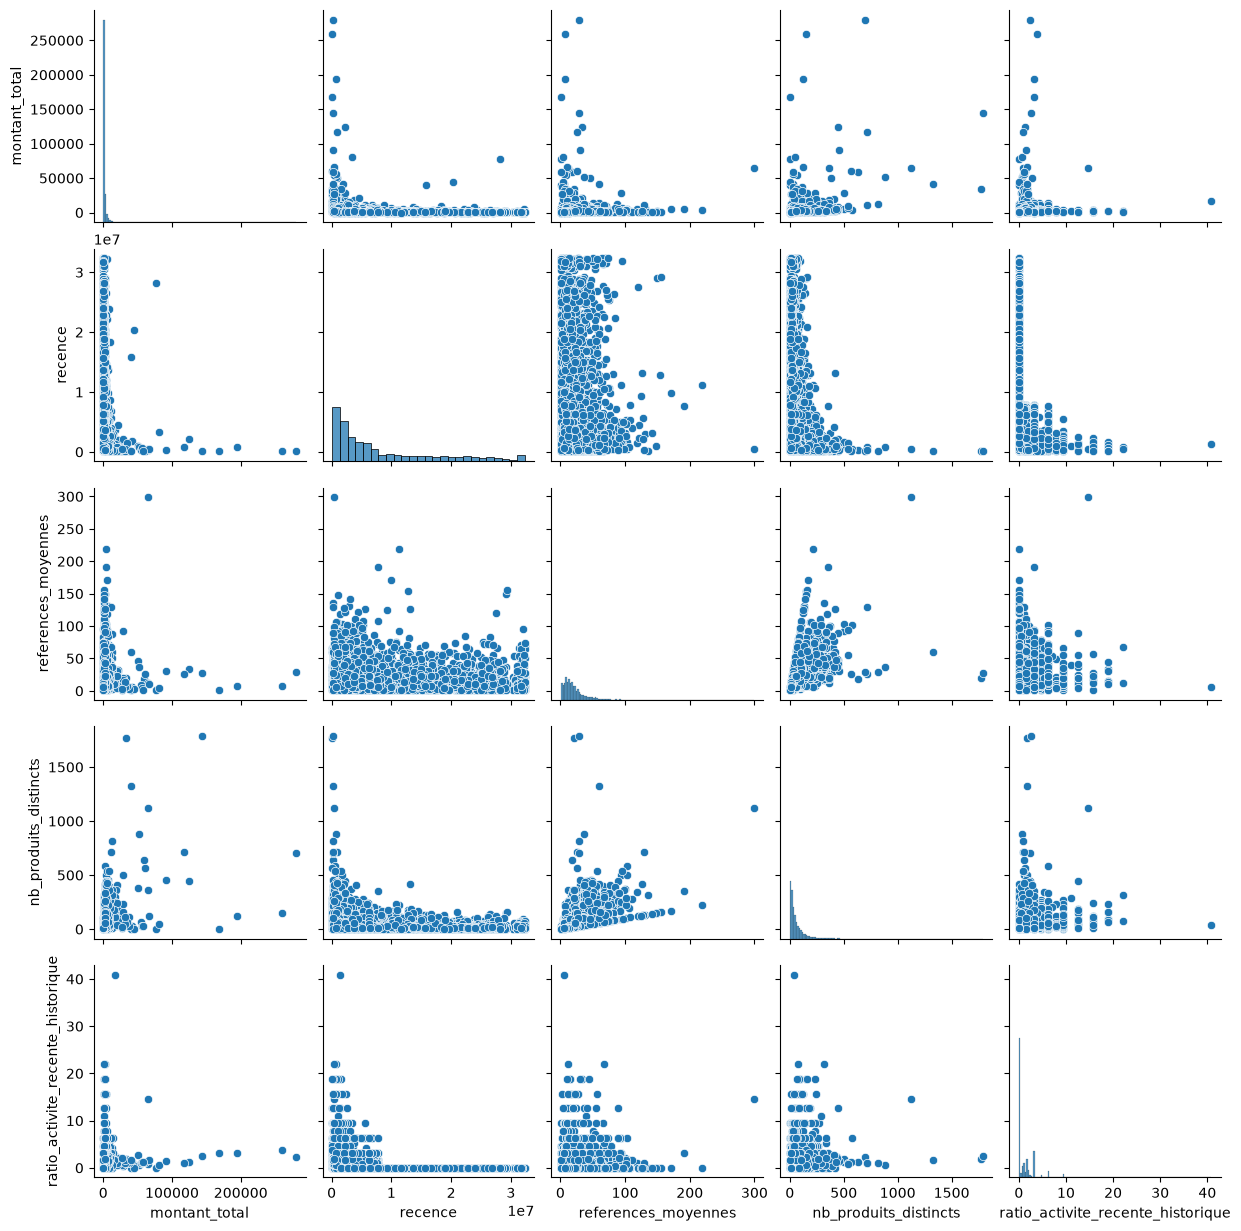

In [66]:
import seaborn as sns

sns.pairplot(data)

In [76]:
data[data.select_dtypes(include="number").columns] = np.log1p(
    data[data.select_dtypes(include="number").columns]
)
data

,montant_total,recence,references_moyennes,nb_produits_distincts,ratio_activite_recente_historique,country
CustomerID,,,,,,
12346.0,11.253955,17.154000,0.693147,0.693147,0.000000,United Kingdom
12347.0,8.368925,12.422316,3.295837,4.644391,0.814381,Iceland
12348.0,7.494564,15.697266,2.047693,3.135494,0.716936,Finland
12349.0,7.472245,14.317704,4.304065,4.304065,0.000000,Italy
12350.0,5.815324,17.106109,2.890372,2.890372,0.000000,Norway
...,...,...,...,...,...,...
18280.0,5.201806,16.994809,2.397895,2.397895,0.000000,United Kingdom
18281.0,4.404522,16.565689,2.079442,2.079442,0.000000,United Kingdom
18282.0,5.187665,13.451985,1.945910,2.564949,1.421769,United Kingdom


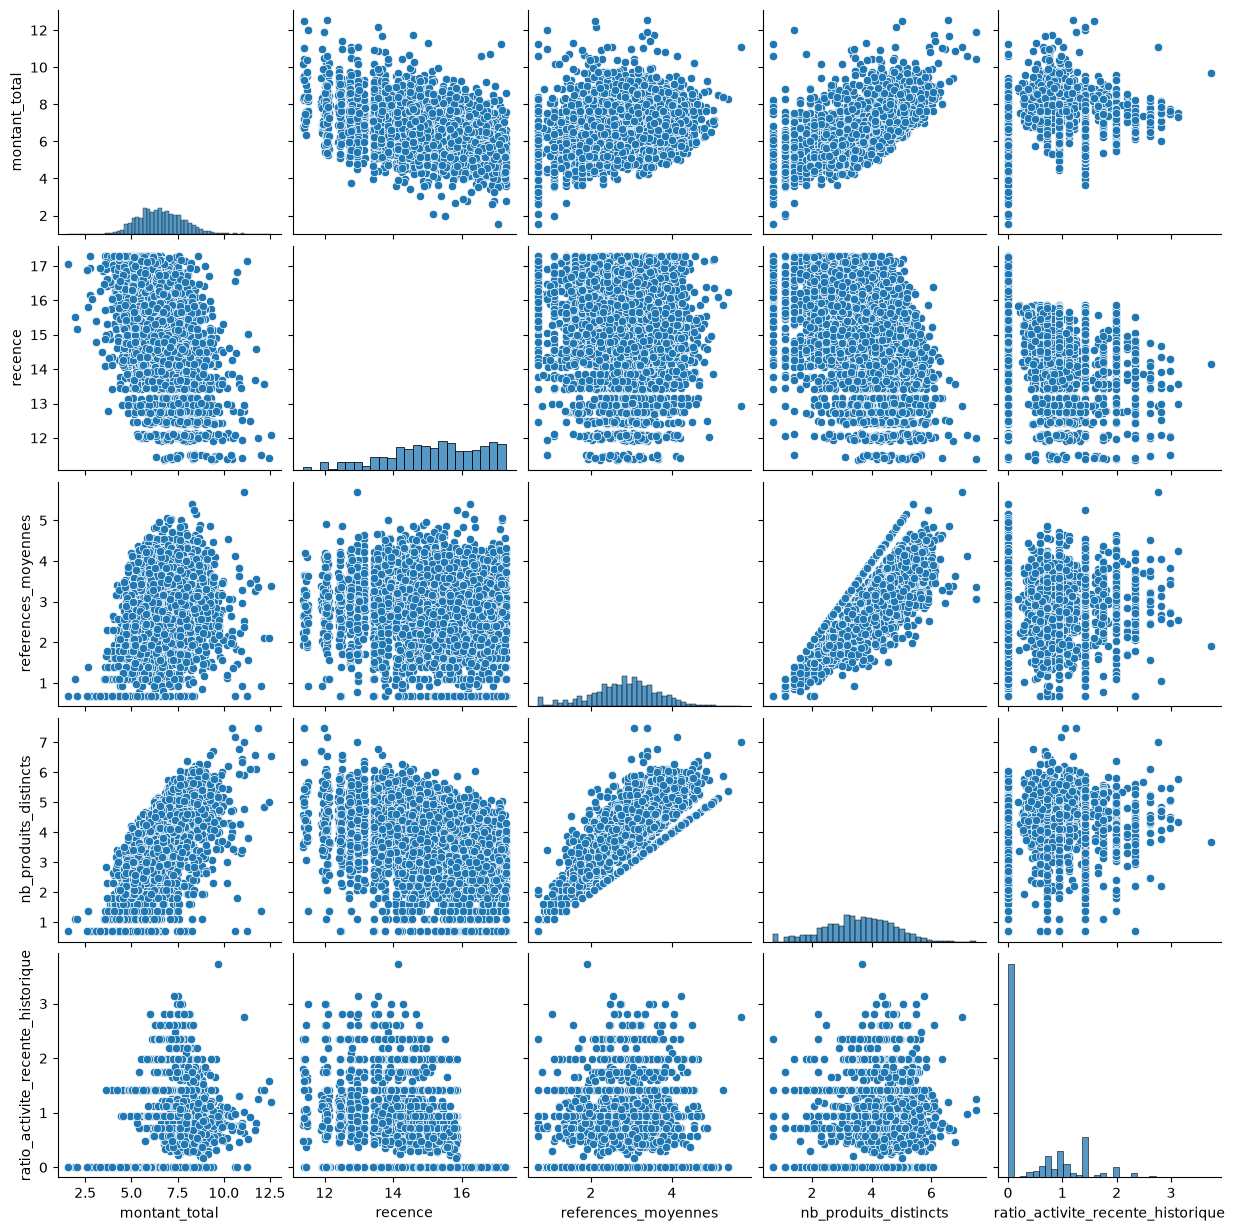

In [77]:
sns.pairplot(data)

In [78]:
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn import set_config

set_config(transform_output="pandas")

encoder = ColumnTransformer(
    [("encoder", OrdinalEncoder(), ["country"])],
    verbose_feature_names_out=False,
    remainder="passthrough",
)
pipeline = make_pipeline(encoder, StandardScaler())
data_encoder = pipeline.fit_transform(data)
data_encoder

,country,montant_total,recence,references_moyennes,nb_produits_distincts,ratio_activite_recente_historique
CustomerID,,,,,,
12346.0,0.292508,3.706225,1.436033,-2.625675,-2.526376,-0.764785
12347.0,-2.781458,1.411843,-1.984457,0.595886,0.965881,0.444036
12348.0,-3.428609,0.716489,0.382974,-0.949044,-0.367738,0.299394
12349.0,-2.457882,0.698739,-0.614299,1.843852,0.665088,-0.764785
12350.0,-1.487156,-0.618962,1.401413,0.094009,-0.584387,-0.764785
...,...,...,...,...,...,...
18280.0,0.292508,-1.106875,1.320955,-0.515570,-1.019656,-0.764785
18281.0,0.292508,-1.740933,1.010748,-0.909746,-1.301117,-0.764785
18282.0,0.292508,-1.118121,-1.240119,-1.075028,-0.872007,1.345608


In [79]:
from sklearn.decomposition import PCA

data_pca = PCA(random_state=42).fit_transform(data_encoder)
data_pca

,pca0,pca1,pca2,pca3,pca4,pca5
CustomerID,,,,,,
12346.0,-1.475757,-1.805148,-0.634828,-3.400391,3.103246,-1.647203
12347.0,2.582294,-0.234805,-2.657493,-0.554252,-1.021690,-0.127914
12348.0,-0.068630,-0.349699,-3.607784,-0.213334,0.584705,0.102160
12349.0,1.505931,1.740962,-2.147003,-0.325304,-0.979695,-0.599826
12350.0,-1.370311,1.144057,-1.462893,0.257162,0.307902,-0.079597
...,...,...,...,...,...,...
18280.0,-2.144641,0.405152,0.216067,0.230703,0.287213,0.005123
18281.0,-2.631336,-0.021536,0.207301,0.450276,-0.194456,0.188490
18282.0,-0.430933,-2.144651,0.171088,1.051762,-0.821419,0.070418


In [82]:
import plotly.express as px

fig = px.scatter_3d(
    data_pca, x=data_pca["pca0"], y=data_pca["pca1"], z=data_pca["pca2"]
)
fig.update_traces(marker_size=3)
fig.show()